In [37]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, os, json

pd.set_option('display.max_columns', None)

# DADOS

In [38]:
df_dynamic = pd.read_csv('Analysis/DynamicTests/output.csv')
df_dynamic

,time,ref_az,ref_roll,ref_q1,ref_sample_time,ref_q3,ref_q0,ref_la_pos_mon_d,ref_wx,ref_wz,ref_ay,ref_pitch,ref_yaw,ref_q2,ref_ax,ref_wy,target_wy,target_yaw,target_pitch,target_ax,target_ay,target_q1,target_wz,target_q3,target_roll,target_q0,target_az,target_q2,target_wx,target_e
0,0.0,-0.23550,91.615951,0.7151,905000000.0,0.07618,0.6928,0.07731,2.807493,4.977284,-9.797,-2.034000,10.456480,0.053010,-0.05341,-66.749583,-91.70012,351.928,0.566,-0.204047,9.484855,0,-0.12853,0,-1.547,0,0.805861,0,-1.04879,0.0
1,0.1,-0.44210,92.303501,0.7209,5000000.0,0.04384,0.6915,0.08007,3.242368,2.971932,-9.735,-2.264902,4.897070,0.017120,-0.41220,-49.537931,-71.89229,342.952,0.293,-0.263005,9.898479,0,0.12185,0,-1.759,0,0.539964,0,-1.88971,0.0
2,0.2,-0.65480,92.360797,0.7216,105000000.0,0.02795,0.6918,0.08320,0.164324,-6.210862,-9.783,-1.840340,2.709517,0.005945,0.07146,-8.771984,-58.17557,337.082,0.157,-0.523665,9.480785,0,-1.76192,0,-1.928,0,0.254532,0,-1.21886,0.0
3,0.3,-0.55400,92.819163,0.7240,205000000.0,0.03840,0.6884,0.08568,6.359832,-1.837476,-9.898,-1.617460,4.685649,0.019880,0.27240,29.077608,-38.35434,332.095,0.405,-0.987853,9.614773,0,-5.45139,0,-1.940,0,0.279097,0,1.43899,0.0
4,0.4,-0.42470,93.392121,0.7259,305000000.0,0.07717,0.6816,0.08755,8.199026,6.583285,-9.899,-2.400693,10.370536,0.051460,0.18020,67.895499,0.49075,330.255,0.981,-0.356040,9.951533,0,-5.83280,0,-1.789,0,0.090123,0,1.05716,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,44.6,0.17720,76.031499,0.1422,505000000.0,0.69970,-0.3265,10.00000,-2.610969,-1.883885,-9.654,-37.116206,-159.396859,0.619400,0.04383,-0.700727,40.60773,23.407,-1.184,0.695566,9.926576,0,-6.95774,0,0.381,0,-0.559028,0,2.44324,0.0
447,44.7,-0.06857,76.031499,0.1406,605000000.0,0.70150,-0.3236,10.00000,-0.101757,-5.032288,-9.772,-36.720865,-159.568746,0.619200,-0.02459,-1.295458,-8.29896,25.142,-0.815,1.399144,9.948533,0,-0.75012,0,0.523,0,-0.578347,0,0.08862,0.0
448,44.8,-0.17420,76.604457,0.1389,705000000.0,0.70150,-0.3187,10.00000,2.079264,-5.209905,-9.621,-36.256769,-160.141704,0.622200,-0.03938,-3.759749,-47.59066,22.021,-0.880,0.624380,9.882681,0,2.96320,0,0.337,0,-0.250913,0,-5.13846,0.0
449,44.9,-0.07313,76.661753,0.1369,805000000.0,0.70240,-0.3161,10.00000,0.558405,-2.673994,-9.902,-35.884347,-160.256295,0.622800,0.26430,1.200920,-72.14091,15.951,-1.098,0.349382,9.600220,0,0.30823,0,-0.018,0,0.205410,0,-3.42173,0.0


In [39]:
df_static = pd.read_csv('Analysis/StaticTests/output.csv')
df_static

,ref_az,time,ref_roll,ref_q1,ref_sample_time,ref_q3,ref_q0,ref_la_pos_mon_d,ref_wx,ref_wz,ref_ay,ref_pitch,ref_yaw,ref_q2,ref_ax,ref_wy,target_wy,target_yaw,target_pitch,target_ax,target_ay,target_q1,target_wz,target_q3,target_roll,target_q0,target_az,target_q2,target_wx,target_e
0,-0.44210,0.000000,92.303501,0.7209,5000000.0,0.04384,0.6915,0.08007,3.242368,2.971932,-9.735,-2.264902,4.897070,0.017120,-0.41220,-49.537931,-88.96987,351.027,0.544,-0.017211,9.935411,0,0.67168,0,-1.557,0,0.929719,0,-0.86342,0.0
1,-0.65480,0.099214,92.360797,0.7216,105000000.0,0.02795,0.6918,0.08320,0.164324,-6.210862,-9.783,-1.840340,2.709517,0.005945,0.07146,-8.771984,-71.89229,342.952,0.293,-0.263005,9.898479,0,0.12185,0,-1.759,0,0.539964,0,-1.88971,0.0
2,-0.55400,0.204345,92.819163,0.7240,205000000.0,0.03840,0.6884,0.08568,6.359832,-1.837476,-9.898,-1.617460,4.685649,0.019880,0.27240,29.077608,-54.93938,335.947,0.169,-0.794898,9.468899,0,-2.95439,0,-1.948,0,0.249197,0,-0.62570,0.0
3,-0.42470,0.299682,93.392121,0.7259,305000000.0,0.07717,0.6816,0.08755,8.199026,6.583285,-9.899,-2.400693,10.370536,0.051460,0.18020,67.895499,-34.64821,331.732,0.450,-0.866790,9.631611,0,-5.89769,0,-1.929,0,0.159780,0,1.71132,0.0
4,-0.45180,0.404275,93.850487,0.7237,405000000.0,0.13380,0.6698,0.08842,9.304835,6.669229,-9.946,-3.566662,18.787286,0.098180,0.16980,89.037641,3.80606,330.277,1.039,-0.353098,10.018689,0,-5.29644,0,-1.776,0,0.044620,0,0.96466,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,0.17720,44.503745,76.031499,0.1422,505000000.0,0.69970,-0.3265,10.00000,-2.610969,-1.883885,-9.654,-37.116206,-159.396859,0.619400,0.04383,-0.700727,57.90495,18.843,-1.804,0.312067,9.600357,0,-7.20663,0,0.316,0,0.122407,0,0.29527,0.0
446,-0.06857,44.598816,76.031499,0.1406,605000000.0,0.70150,-0.3236,10.00000,-0.101757,-5.032288,-9.772,-36.720865,-159.568746,0.619200,-0.02459,-1.295458,36.41283,23.791,-1.124,0.718690,9.923879,0,-5.81257,0,0.397,0,-0.580828,0,2.63445,0.0
447,-0.17420,44.704490,76.604457,0.1389,705000000.0,0.70150,-0.3187,10.00000,2.079264,-5.209905,-9.621,-36.256769,-160.141704,0.622200,-0.03938,-3.759749,-13.23356,25.033,-0.804,1.435733,10.020043,0,-0.91399,0,0.526,0,-0.675247,0,0.14077,0.0
448,-0.07313,44.802879,76.661753,0.1369,805000000.0,0.70240,-0.3161,10.00000,0.558405,-2.673994,-9.902,-35.884347,-160.256295,0.622800,0.26430,1.200920,-50.34315,21.528,-0.907,0.564235,9.890105,0,2.97370,0,0.296,0,-0.198742,0,-5.20244,0.0


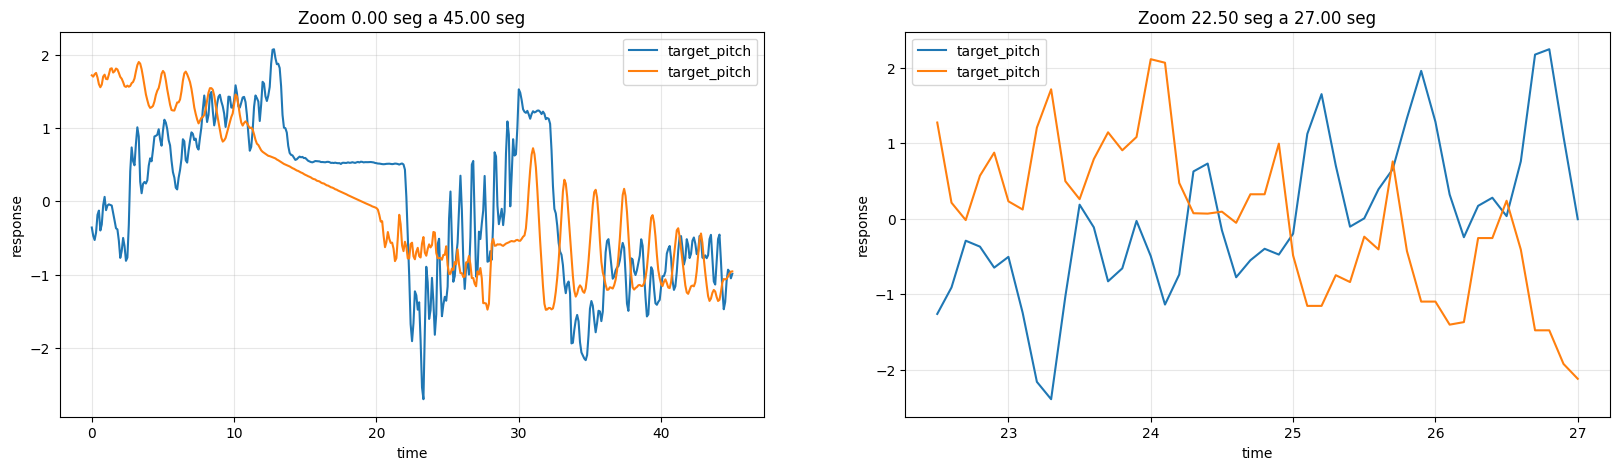

In [40]:
def normalize(array):
    return (array - np.mean(array)) / np.std(array)

def plotViews(df, varname, limits=(0, 1), norm=True):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    values1 = target['target_' + varname] if not norm else normalize(target['target_' + varname])
    values2 = target['ref_' + varname] if not norm else normalize(target['ref_' + varname])

    plt.plot(target.time, values1, label='target_' + varname)
    plt.plot(target.time, values2, label='target_' + varname)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df_dynamic, 'pitch', limits=(0, 1))
plt.subplot(1, 2, 2)
plotViews(df_dynamic,  'pitch', limits=(0.5, 0.6))

# DEFASAGEM

In [41]:
class Phaser:
    def __init__(self, target, reference):
        self.target    = target
        self.reference = reference

    def get(self, df):
        x_norm = normalize(df[self.target])
        y_norm = normalize(df[self.reference])
        
        correlation = np.correlate(y_norm, x_norm, mode='full')
        lags = np.arange(-len(df) + 1, len(df))
        lag  = lags[np.argmax(correlation)]
        return lag

    def set(self, df, lag):
        if lag == 0:
            return df

        df.loc[:, self.target] = df[self.target].shift(lag)
        df = df.dropna().reset_index(drop=True)
        return df


phaser = Phaser('target_wz', 'ref_wz')
lag    = phaser.get(df_static)
df_static = phaser.set(df_static, lag)
print('static lag:', lag, 'samples')

phaser = Phaser('target_wz', 'ref_wz')
lag    = phaser.get(df_dynamic)
df_dynamic = phaser.set(df_dynamic, lag)
print('static lag:', lag, 'samples')

static lag: -20 samples
static lag: -19 samples


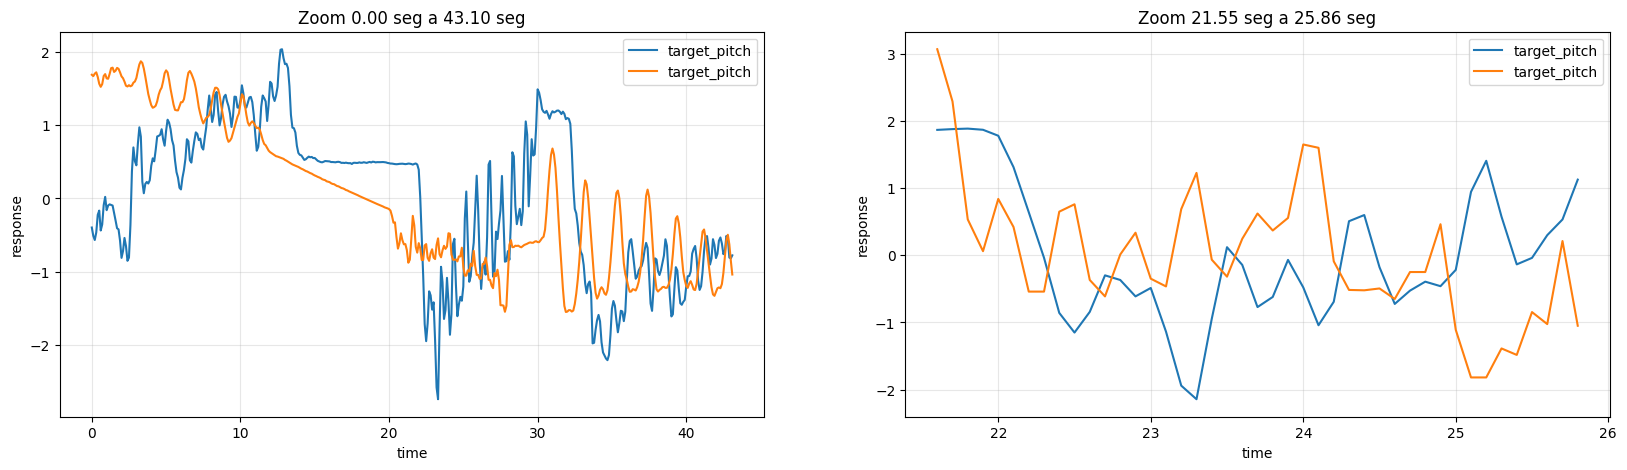

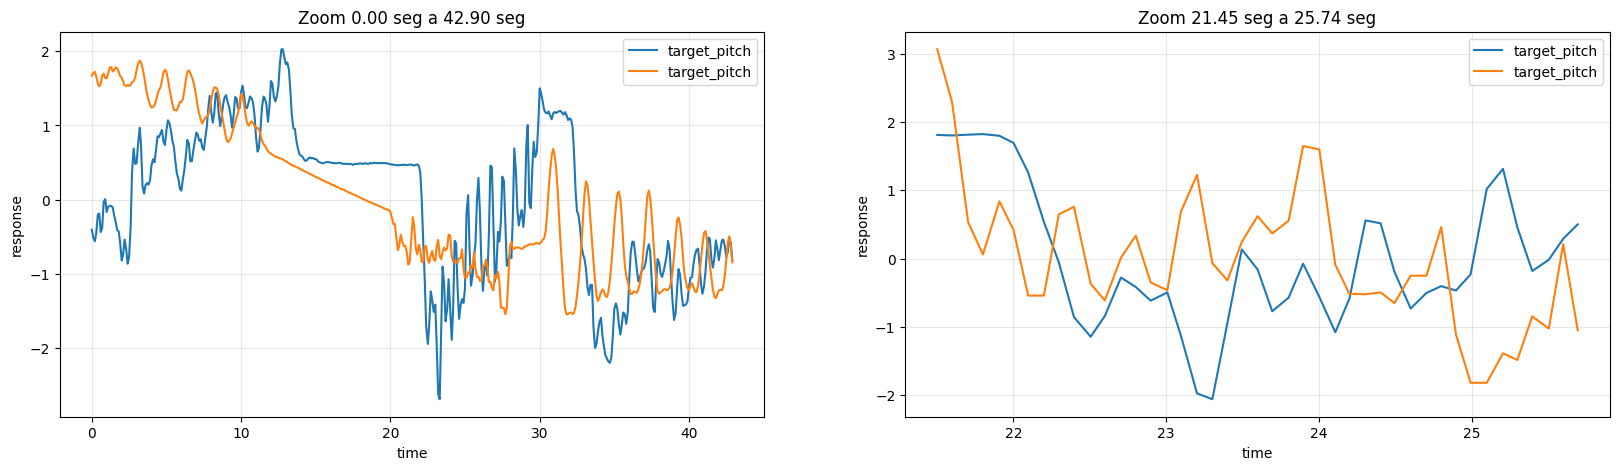

In [42]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df_dynamic, 'pitch', limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df_dynamic,  'pitch', limits=(0.5, 0.6))

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df_static, 'pitch', limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df_static,  'pitch', limits=(0.5, 0.6))

# CURVE FIT

In [43]:
from scipy.optimize import curve_fit, OptimizeWarning
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=OptimizeWarning)

In [44]:
class TemporalFit:
    def __init__(self, time, xData, yData, max_iter=2100000000):
        self.time  = np.array(time)
        self.xData = np.array(xData)
        self.yData = np.array(yData)
        self.max_iter = max_iter
        self.coefs = []

    def f(self, x, a, b):
        return a*x + b

    def apply(self, data):
        if len(self.coefs) == 0:
            return None

        return self.f(np.array(data), *self.coefs)
    
    def update(self):
        result      = curve_fit(self.f, self.xData, self.yData, maxfev=self.max_iter)
        self.coefs  = [float(round(coef, 12)) for coef in list(result[0])]
        self.yModel = self.apply(self.xData)
        
        self.error = (self.yData - self.yModel)
        self.rmse  = np.sqrt(np.mean(self.error**2))
        self.mae   = np.mean(np.abs(self.error))
        self.max_error = np.max(np.abs(self.error))

        self.scale_factor_error = np.abs(1.0 - self.coefs[0]) * 100 
        self.std_noise = self.error.std()
        
        ss_res = np.sum(self.error**2) 
        ss_tot = np.sum((self.yData - np.mean(self.yData))**2) 

        if ss_tot == 0:
            self.r2 = 1.0 if ss_res == 0 else 0.0
        else:
            self.r2 = 1 - float(ss_res / ss_tot)

    def plot(self, view_limits=(0, 1)):
        t_max = self.time[-1]
        
        mask = ((self.time >= t_max * view_limits[0]) & (self.time <= t_max * view_limits[1])) if view_limits else slice(None)
        t_plot   = self.time[mask]
        x_plot   = self.xData[mask]
        y_plot   = self.yData[mask]
        mod_plot = self.yModel[mask]
        err_plot = self.error[mask]
        title = f" (Zoom: {t_max * view_limits[0]:.1f}s a {t_max * view_limits[1]:.1f}s)" if view_limits else ""

        plt.figure(figsize=(20, 5))
        plt.subplot(1, 2, 1)
        plt.plot(t_plot, y_plot, color='blue', label='reference')
        plt.plot(t_plot, mod_plot, color='red', label='model')
        plt.xlabel('time'); plt.ylabel('response')
        plt.legend(); plt.title(f'R2 Score {self.r2:.3f}')
        plt.grid()

        plt.subplot(1, 2, 2)
        plt.plot(t_plot, err_plot, color='blue')
        plt.xlabel('time'); plt.ylabel('response')
        plt.ylim(-self.max_error*3, self.max_error*3)
        plt.title(f'temporal error (max={self.max_error:.3f} | rmse={self.rmse:.3f})')
        plt.grid(); plt.show()

    def display(self):
        display(pd.DataFrame([{'r2': self.r2, 'mae': self.mae, 'rmse': self.rmse, 'max_error': self.max_error}]))

Variable: pitch


,r2,mae,rmse,max_error
0,0.272723,8.312652,10.671769,26.448067


Análise de Calibração - pitch
Precisão: ±21.3435 m/s² (95% de confiança)
Bias do Sensor:  -27.2384 m/s²
Fator de Escala: 2.7192


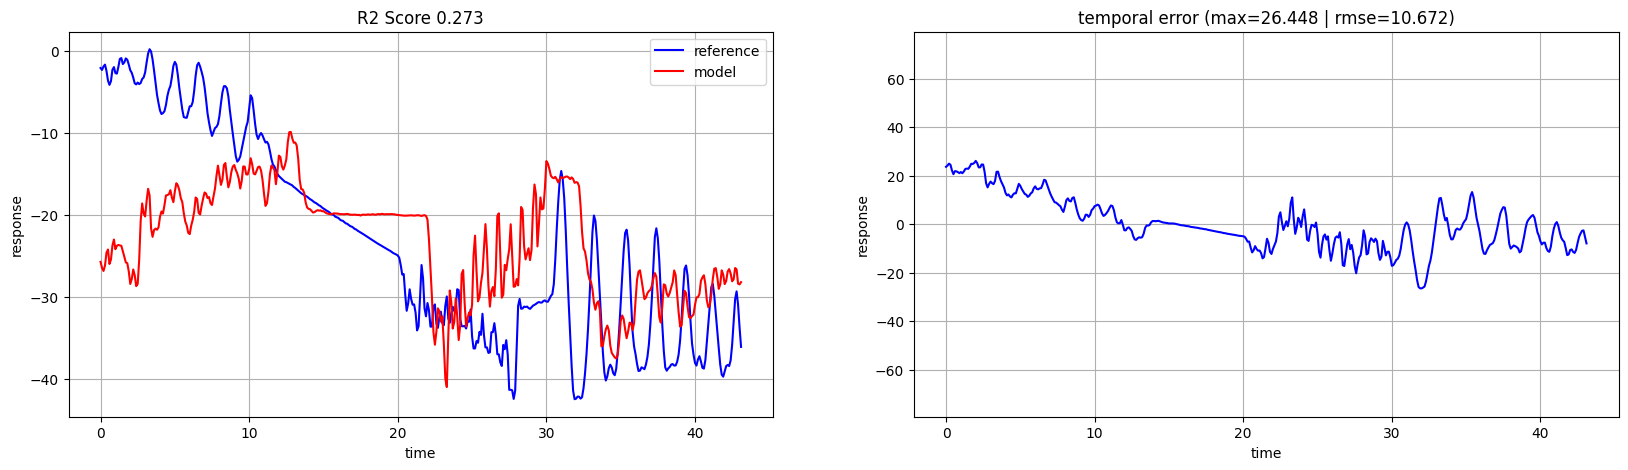

In [45]:
var = 'pitch'
print('Variable:', var)
model = TemporalFit(df_dynamic.time, df_dynamic['target_' + var], df_dynamic['ref_' + var])
model.update()
model.display()

df_dynamic['model_' + var] = model.yModel
erro_medio = model.mae
erro_pico  = model.rmse
escala     = model.coefs[0] # Sensibilidade (o 'a' de ax + b)
bias       = model.coefs[1] # Offset (o 'b' de ax + b)
precision  = 2 * model.error.std() # Calculando o intervalo de 95% de confiança

print(f'Análise de Calibração - {var}')
print(f'Precisão: ±{precision:.4f} m/s² (95% de confiança)')
print(f'Bias do Sensor:  {bias:.4f} m/s²')
print(f'Fator de Escala: {escala:.4f}')
model.plot()

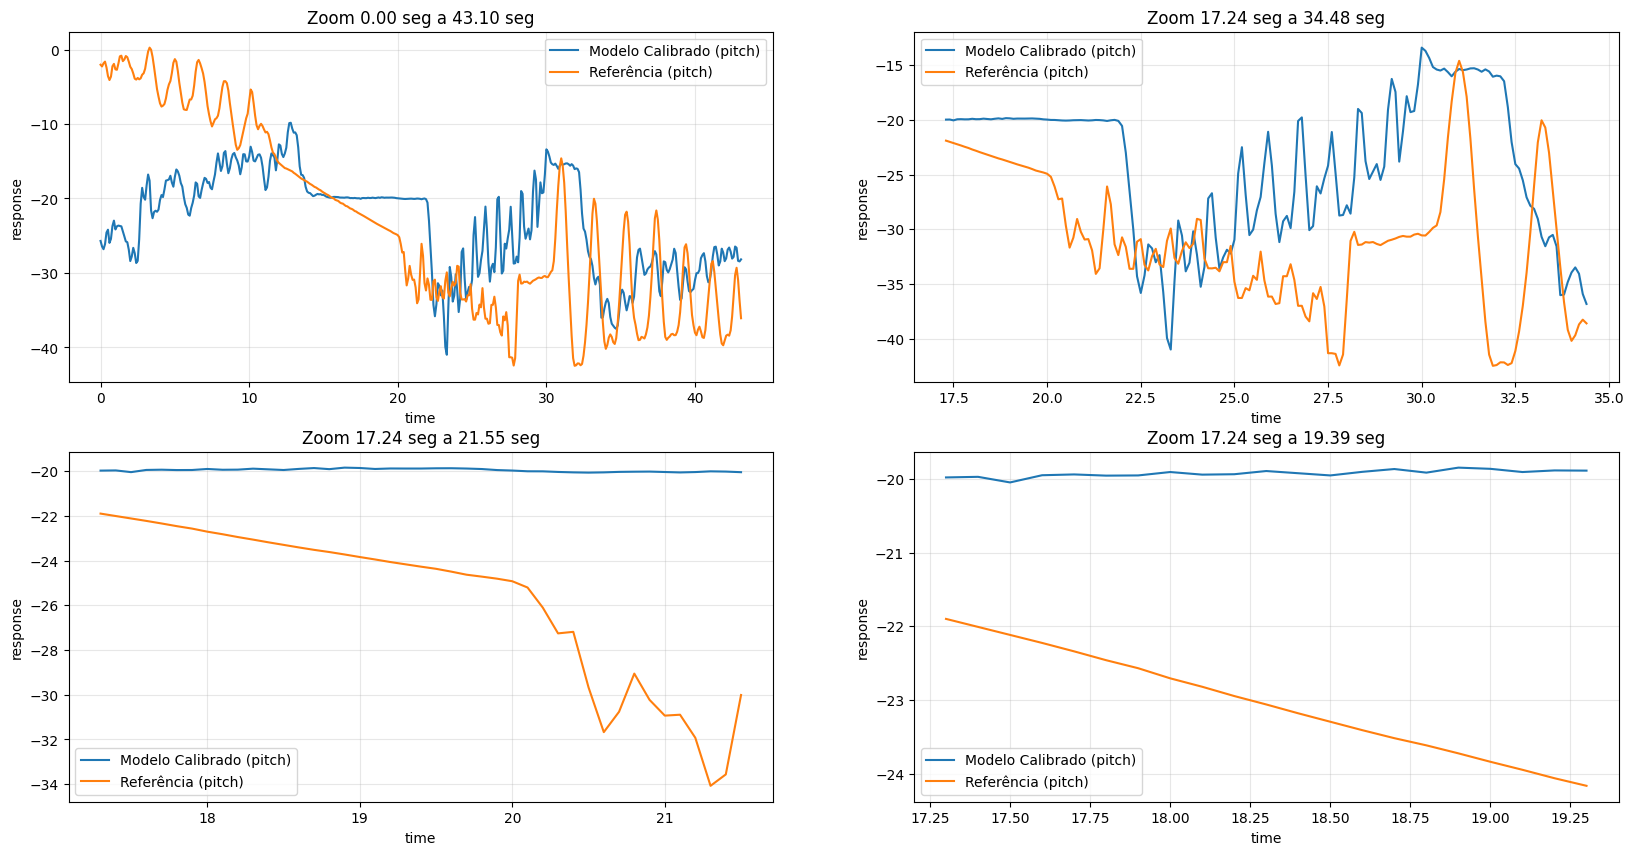

In [46]:
def plotModel(df, var, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]
    
    plt.plot(target.time, target['model_' + var], label=f'Modelo Calibrado ({var})')
    plt.plot(target.time, target['ref_' + var], label=f'Referência ({var})')
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 10))
plt.subplot(2, 2, 1)
plotModel(df_dynamic, var, limits=(0, 1))

plt.subplot(2, 2, 2)
plotModel(df_dynamic, var, limits=(0.4, .8))

plt.subplot(2, 2, 3)
plotModel(df_dynamic, var, limits=(0.4, .5))

plt.subplot(2, 2, 4)
plotModel(df_dynamic, var, limits=(0.4, .45))
plt.show()

# GERANDO RELATÓRIO

Variable: pitch


,r2,mae,rmse,max_error
0,0.272723,8.312652,10.671769,26.448067


Análise de Calibração - pitch
Precisão: ±21.3435 m/s² (95% de confiança)
Bias do Sensor:  -27.2384 m/s²
Fator de Escala: 2.7192


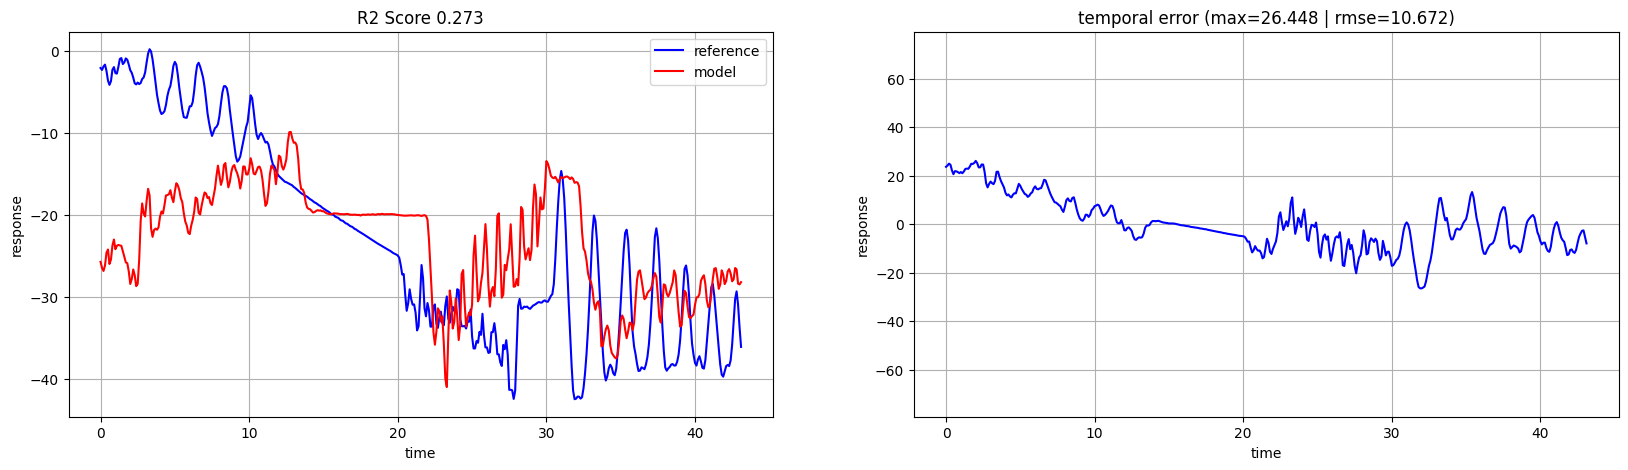

[export] Resultados exportados para: Certificate/results/target_pitch
  → Certificate/results/target_pitch/ref_vs_model.png
  → Certificate/results/target_pitch/error.png
  → Certificate/results/target_pitch/metrics.json

------------------------------------------------------------------------------------------------------------------------------------------------

Variable: roll


,r2,mae,rmse,max_error
0,0.000166,12.118085,14.125007,34.164381


Análise de Calibração - roll
Precisão: ±28.2500 m/s² (95% de confiança)
Bias do Sensor:  85.0255 m/s²
Fator de Escala: 0.1737


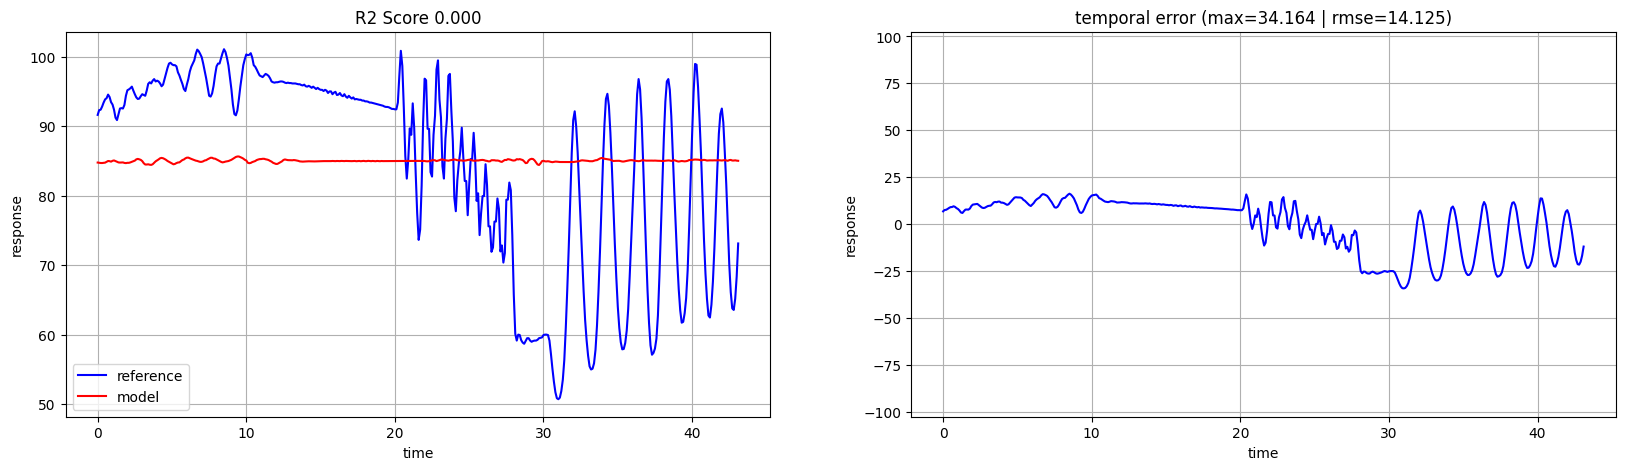

[export] Resultados exportados para: Certificate/results/target_roll
  → Certificate/results/target_roll/ref_vs_model.png
  → Certificate/results/target_roll/error.png
  → Certificate/results/target_roll/metrics.json

------------------------------------------------------------------------------------------------------------------------------------------------

Variable: yaw


,r2,mae,rmse,max_error
0,0.027186,68.876785,93.458465,250.7857


Análise de Calibração - yaw
Precisão: ±186.9169 m/s² (95% de confiança)
Bias do Sensor:  38.3290 m/s²
Fator de Escala: 0.0964


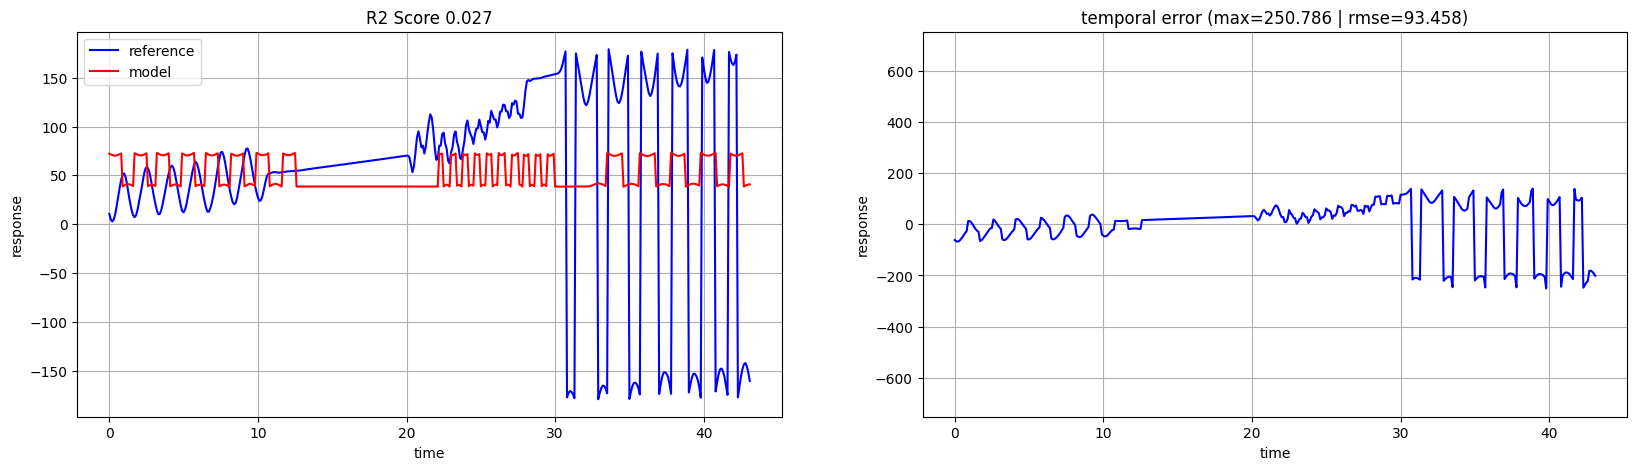

[export] Resultados exportados para: Certificate/results/target_yaw
  → Certificate/results/target_yaw/ref_vs_model.png
  → Certificate/results/target_yaw/error.png
  → Certificate/results/target_yaw/metrics.json

------------------------------------------------------------------------------------------------------------------------------------------------

Variable: wx


,r2,mae,rmse,max_error
0,0.002553,3.146514,4.220517,18.772081


Análise de Calibração - wx
Precisão: ±8.4410 m/s² (95% de confiança)
Bias do Sensor:  1.6044 m/s²
Fator de Escala: 0.0522


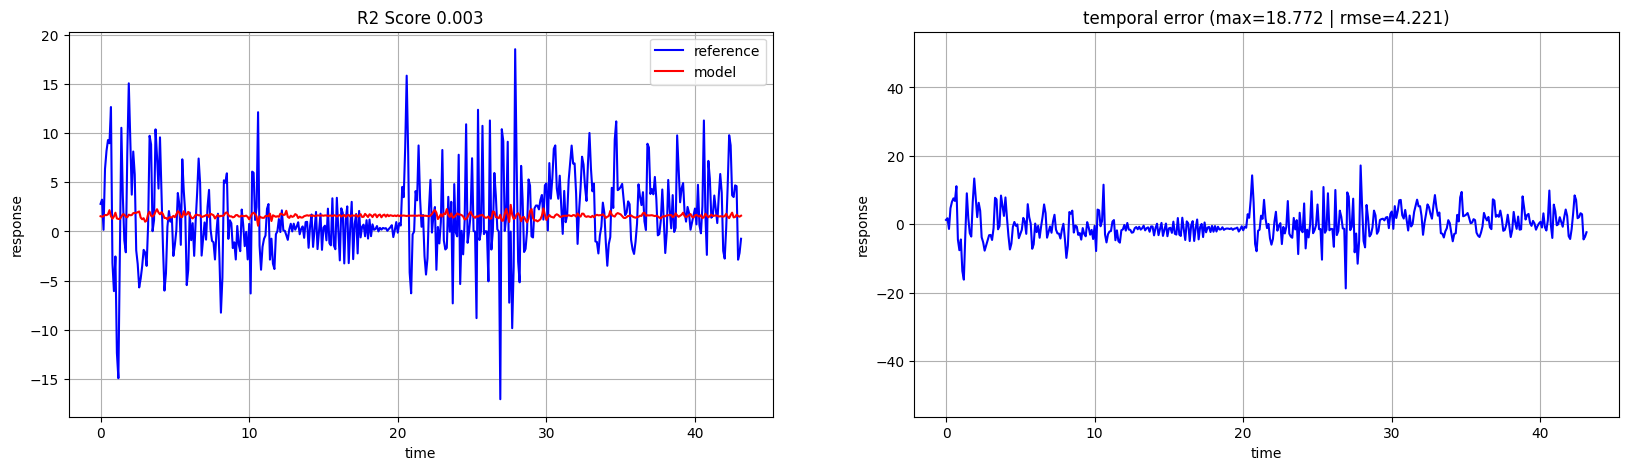

[export] Resultados exportados para: Certificate/results/target_wx
  → Certificate/results/target_wx/ref_vs_model.png
  → Certificate/results/target_wx/error.png
  → Certificate/results/target_wx/metrics.json

------------------------------------------------------------------------------------------------------------------------------------------------

Variable: wy


,r2,mae,rmse,max_error
0,0.072474,43.730678,56.74668,155.148126


Análise de Calibração - wy
Precisão: ±113.4934 m/s² (95% de confiança)
Bias do Sensor:  3.4197 m/s²
Fator de Escala: 0.2161


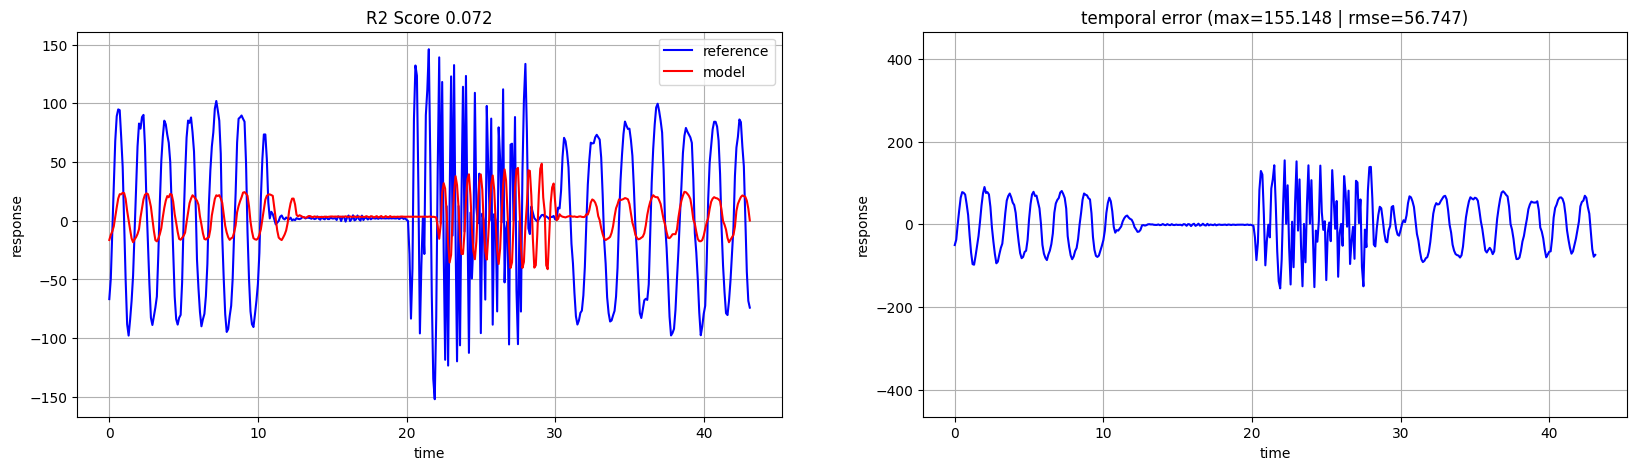

[export] Resultados exportados para: Certificate/results/target_wy
  → Certificate/results/target_wy/ref_vs_model.png
  → Certificate/results/target_wy/error.png
  → Certificate/results/target_wy/metrics.json

------------------------------------------------------------------------------------------------------------------------------------------------

Variable: wz


,r2,mae,rmse,max_error
0,0.644968,2.133919,3.637266,20.0749


Análise de Calibração - wz
Precisão: ±7.2745 m/s² (95% de confiança)
Bias do Sensor:  1.1869 m/s²
Fator de Escala: 0.7249


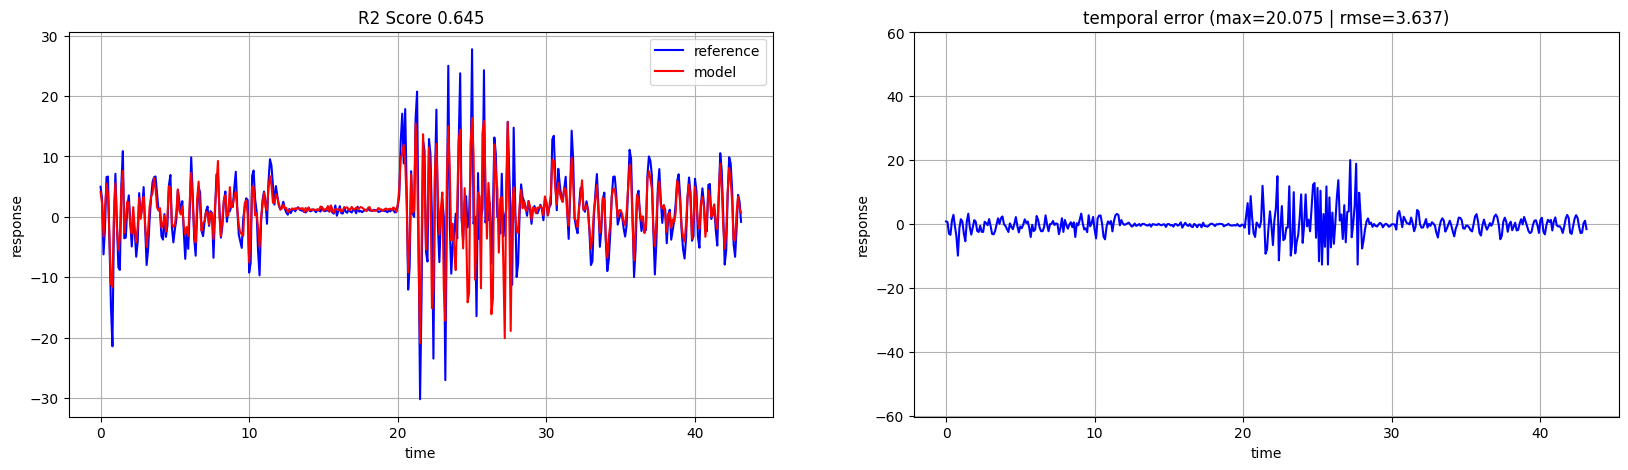

[export] Resultados exportados para: Certificate/results/target_wz
  → Certificate/results/target_wz/ref_vs_model.png
  → Certificate/results/target_wz/error.png
  → Certificate/results/target_wz/metrics.json

------------------------------------------------------------------------------------------------------------------------------------------------



In [ ]:
class ResultExporter:
    PURPLE_MID  = '#6A3CBC'
    PINK_ACCENT = '#E91E63'

    def __init__(self, basePath, rawVar, model, calibration=None):
        self.basePath = basePath
        self.rawVar = rawVar
        self.model = model
        self.calibration = calibration
        self.outputDir = os.path.join(basePath, 'results', rawVar)

    def _ensureDir(self):
        os.makedirs(self.outputDir, exist_ok=True)

    def _makePlot(self, plotType, width=250, height=150):
        fig, ax = plt.subplots(figsize=(width / 72, height / 72), dpi=150)
        model = self.model
        label = self.rawVar.capitalize()

        if plotType == 'ref':
            ax.plot(model.time, model.yData, color=self.PURPLE_MID, linewidth=0.8, label='Referência')
            ax.plot(model.time, model.yModel, color=self.PINK_ACCENT, linewidth=0.8, label='Medido')
            ax.legend(fontsize=6, loc='upper right')
            ax.set_ylabel('Ângulo (deg)', fontsize=7)
            ax.set_title(f'{label}: Referência vs. Medido', fontsize=8, fontweight='bold')
        else:
            ax.plot(model.time, model.error, color=self.PURPLE_MID, linewidth=0.8, label='Erro')
            ax.legend(fontsize=6, loc='upper right')
            ax.set_ylabel('Erro (deg)', fontsize=7)
            ax.set_ylim(-max(model.error*3.5), max(model.error*3.5))
            ax.set_title(f'Erro Temporal – {label}', fontsize=8, fontweight='bold')

        ax.set_xlabel('Tempo (s)', fontsize=7)
        ax.tick_params(axis='both', labelsize=6)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        plt.tight_layout(pad=0.5)
        return fig

    def exportPlots(self):
        self._ensureDir()

        figRef = self._makePlot('ref')
        refPath = os.path.join(self.outputDir, 'ref_vs_model.png')
        figRef.savefig(refPath, format='png', dpi=150, bbox_inches='tight')
        plt.close(figRef)

        figErr = self._makePlot('error')
        errPath = os.path.join(self.outputDir, 'error.png')
        figErr.savefig(errPath, format='png', dpi=150, bbox_inches='tight')
        plt.close(figErr)

        return refPath, errPath

    def exportMetrics(self):
        self._ensureDir()
        model = self.model

        precision = 2 * model.error.std()

        metrics = {
            'r2': float(round(model.r2, 6)),
            'mae': float(round(model.mae, 6)),
            'rmse': float(round(model.rmse, 6)),
            'maxError': float(round(model.max_error, 6)),
            'scaleFactorError': float(round(model.scale_factor_error, 6)),
            'stdNoise': float(round(model.std_noise, 6)),
            'coefs': [float(c) for c in model.coefs],
            'precision': float(round(precision, 6)),
        }

        path = os.path.join(self.outputDir, 'metrics.json')
        with open(path, 'w', encoding='utf-8') as f:
            json.dump(metrics, f, indent=2, ensure_ascii=False)

        return path

    def exportCalibration(self):
        self._ensureDir()
        if self.calibration is None:
            return None

        calDf = self.calibration.get()
        tests = []
        for idx, row in calDf.iterrows():
            tests.append({
                'name': str(idx),
                'requirement': float(row['Test requirement']),
                'measured': float(row['Value Measured']),
                'status': str(row['Status']),
            })

        data = {'tests': tests}
        path = os.path.join(self.outputDir, 'calibration.json')
        with open(path, 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=2, ensure_ascii=False)

        return path

    def export(self):
        self._ensureDir()
        refPath, errPath = self.exportPlots()
        metricsPath = self.exportMetrics()
        calPath = self.exportCalibration()
        return self.outputDir


for var in ['pitch', 'roll', 'yaw', 'wx', 'wy', 'wz']:
    print('Variable:', var)
    model = TemporalFit(df_dynamic.time, df_dynamic['target_' + var], df_dynamic['ref_' + var])
    model.update()
    model.display()

    df_dynamic['model_' + var] = model.yModel
    erro_medio = model.mae
    erro_pico  = model.rmse
    escala     = model.coefs[0] # Sensibilidade (o 'a' de ax + b)
    bias       = model.coefs[1] # Offset (o 'b' de ax + b)
    precision  = 2 * model.error.std() # Calculando o intervalo de 95% de confiança

    print(f'Análise de Calibração - {var}')
    print(f'Precisão: ±{precision:.4f} m/s² (95% de confiança)')
    print(f'Bias do Sensor:  {bias:.4f} m/s²')
    print(f'Fator de Escala: {escala:.4f}')
    model.plot()
    
    exporter = ResultExporter('Certificate', 'target_' + var, model)
    exporter.export()
    print('\n------------------------------------------------------------------------------------------------------------------------------------------------\n')